# Agregation et Preparation des Donnees — Ligue 1 v3

**Nouveautes de cette version :**
- Stats separees selon le lieu (domicile / exterieur)
- **Moyennes mobiles** sur les 5 derniers matchs (`rolling averages`) pour capturer la forme recente
- Le `.shift(1)` garantit qu'aucune information du match courant n'est incluse → pas de data leakage

**Pourquoi les rolling averages ?**
La moyenne de la saison entiere efface le moment d'une equipe. Un team qui a perdu ses 5 derniers
matchs a une moyenne saison correcte mais est en mauvaise forme — information cruciale pour predire.

## 1. Imports et configuration

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)
print('Imports OK')

Imports OK


## 2. Chargement et concatenation des sources

In [26]:
df_2022_2023_API = pd.read_csv('../Data/dataset/part1/ligue1_2022_completed.csv')
df_2023_2024_API = pd.read_csv('../Data/dataset/part1/ligue1_2023_completed.csv')
df_2024_2025_API = pd.read_csv('../Data/dataset/part1/ligue1_2024_completed.csv')

df_2022_2023 = pd.read_csv('../Data/dataset/part2/2022_2023.csv')
df_2023_2024 = pd.read_csv('../Data/dataset/part2/2023_2024.csv')
df_2024_2025 = pd.read_csv('../Data/dataset/part2/2024_2025.csv')
df_2025_2026 = pd.read_csv('../Data/dataset/part2/2025_2026.csv')

dataset1 = pd.concat([df_2022_2023_API, df_2023_2024_API, df_2024_2025_API])
dataset2 = pd.concat([df_2022_2023, df_2023_2024, df_2024_2025, df_2025_2026])

print(f'Dataset1 (API)     : {dataset1.shape}')
print(f'Dataset2 (externe) : {dataset2.shape}')

Dataset1 (API)     : (996, 40)
Dataset2 (externe) : (1234, 161)


## 3. Harmonisation et fusion

In [27]:
dataset1['Date'] = pd.to_datetime(dataset1['fixture.date']).dt.date
dataset2['Date'] = pd.to_datetime(dataset2['Date'], dayfirst=True).dt.date

dataset2.replace({'Clermont':'Clermont Foot','Troyes':'Estac Troyes','Brest':'Stade Brestois'}, inplace=True)
dataset1.replace({'Saint Etienne':'St Etienne','Paris Saint Germain':'Paris SG','Stade Brestois 29':'Stade Brestois'}, inplace=True)

dataset1.rename(columns={
    'fixture.referee':'Referee','league.round':'Round',
    'teams.home.name':'HomeTeam','teams.away.name':'AwayTeam',
    'score.fulltime.home':'HomeScore','score.fulltime.away':'AwayScore',
}, inplace=True)

dataset2.rename(columns={
    'FTHG':'HomeScore','FTAG':'AwayScore','FTR':'Result',
    'HS':'HomeShot','AS':'AwayShot','HST':'HomeShotTarget','AST':'AwayShotTarget',
    'HTHG':'HalftimeHomeGoals','HTAG':'HalftimeAwayGoals','HTR':'HalftimeResult',
    'HF':'HomeTeamFouls','AF':'AwayTeamFouls',
    'HC':'HomeTeamCorners','AC':'AwayTeamCorners',
    'HY':'HomeYellowCards','AY':'AwayYellowCards',
    'HR':'HomeRedCards','AR':'AwayRedCards',
}, inplace=True)

merged_df = pd.merge(dataset1, dataset2,
    on=['Date','HomeTeam','AwayTeam','HomeScore','AwayScore'], how='outer')
print(f'Dataset fusionne : {merged_df.shape}')

Dataset fusionne : (1238, 197)


## 4. Nettoyage

In [28]:
merged_df['Round'] = merged_df['Round'].str.replace('Regular Season - ','')
merged_df['Round'] = merged_df['Round'].str.replace('Relegation Round','35')

cols_to_drop = [
    'fixture.id','Referee','Round','fixture.timezone','fixture.date','fixture.timestamp',
    'fixture.periods.first','fixture.periods.second',
    'fixture.venue.id','fixture.venue.name','fixture.venue.city',
    'fixture.status.long','fixture.status.short','fixture.status.elapsed','fixture.status.extra',
    'league.id','league.name','league.country','league.logo','league.flag','league.standings',
    'teams.home.id','teams.home.logo','teams.away.id','teams.home.winner',
    'teams.away.logo','teams.away.winner','Div',
    'score.penalty.home','score.penalty.away','score.extratime.home','score.extratime.away',
    'goals.home','goals.away','score.halftime.home','score.halftime.away',
    'LBCA','LBCD','LBCH','CLCA','CLCD','CLCH','LBA','CLH','CLD','LBH','LBD','CLA',
    'BMGMCH','BVA','BFDH','BFDD','BFDA','BFDCA','BMGMD','BMGMA','BVH','BVD','BMGMH',
    'BVCA','BVCH','BMGMCA','BMGMCD','BFDCH','BFDCD','BVCD','1XBA','1XBH','1XBD',
    '1XBCH','BFCA','BFCD','BFCH','BFD','BFA','BFH','1XBCA','1XBCD',
    'IWD','IWA','IWCH','IWCD','IWCA','IWH',
    'BFE<2.5','BFE>2.5','BFEAHA','BFEAHH','BFED','BFEH','BFECAHA','BFEA','BFECA',
    'BFECAHH','BFECH','BFEC>2.5','BFEC<2.5','BFECD',
    'VCA','VCD','VCH','VCCH','VCCA','VCCD','WHA','WHD','WHH','WHCD','WHCH','WHCA',
    'B365H','B365D','B365A','BWH','BWD','BWA','PSH','PSD','PSA','MaxH','MaxD','MaxA',
    'AvgH','AvgD','AvgA','B365>2.5','B365<2.5','P>2.5','P<2.5','Max>2.5','Max<2.5',
    'Avg>2.5','Avg<2.5','AHh','B365AHH','B365AHA','PAHH','PAHA','MaxAHH','MaxAHA',
    'AvgAHH','AvgAHA','B365CH','B365CD','B365CA','BWCH','BWCD','BWCA','PSCH','PSCD',
    'PSCA','MaxCH','MaxCD','MaxCA','AvgCH','AvgCD','AvgCA','B365C>2.5','B365C<2.5',
    'PC>2.5','PC<2.5','MaxC>2.5','MaxC<2.5','AvgC>2.5','AvgC<2.5','AHCh','B365CAHH',
    'B365CAHA','PCAHH','PCAHA','MaxCAHH','MaxCAHA','AvgCAHH','AvgCAHA'
]
merged_df.drop(cols_to_drop, axis=1, inplace=True)
print(f'Apres nettoyage : {merged_df.shape}')
merged_df.head()

Apres nettoyage : (1238, 23)


,league.season,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
0,2022.0,Lyon,Ajaccio,2,1,2022-08-05,20:00,H,2.0,1.0,H,11.0,8.0,6.0,4.0,10.0,18.0,4.0,3.0,1.0,6.0,1.0,1.0
1,2022.0,Clermont Foot,Paris SG,0,5,2022-08-06,20:00,A,0.0,3.0,A,7.0,18.0,1.0,12.0,13.0,13.0,0.0,6.0,2.0,1.0,0.0,0.0
2,2022.0,Strasbourg,Monaco,1,2,2022-08-06,16:00,A,0.0,1.0,A,11.0,24.0,7.0,11.0,18.0,15.0,3.0,7.0,0.0,2.0,0.0,0.0
3,2022.0,Angers,Nantes,0,0,2022-08-07,14:00,D,0.0,0.0,D,16.0,14.0,6.0,4.0,15.0,13.0,3.0,6.0,3.0,3.0,0.0,0.0
4,2022.0,Lens,Stade Brestois,3,2,2022-08-07,14:00,H,1.0,0.0,H,17.0,6.0,7.0,4.0,16.0,14.0,6.0,3.0,2.0,4.0,0.0,0.0


## 5. Valeurs manquantes et arbitres

In [29]:
merged_df['league.season'] = merged_df['league.season'].fillna('2025')

# referees_df = pd.read_csv('../Data/dataset/referees_list.csv')
# referees_df['Round'] = referees_df['Round'].astype(str)
# referees_df['Date']  = pd.to_datetime(referees_df['Date']).dt.date

# final_df = pd.merge(merged_df, referees_df, on=['Date','HomeTeam'], how='left', suffixes=('','_new'))
# # final_df['Referee'] = final_df['Referee'].fillna(final_df['Referee_new'])
# final_df['Round']   = final_df['Round'].fillna(final_df['Round_new'])
# final_df.drop(['Round_new', 'Referee'], axis=1, inplace=True)

avant = len(merged_df)
final_df = merged_df.dropna(subset=['Result'])
print(f'Lignes sans resultat supprimees : {avant - len(final_df)}')

cols_int = [
    'league.season','HalftimeHomeGoals','HalftimeAwayGoals',
    'HomeShot','AwayShot','HomeShotTarget','AwayShotTarget',
    'HomeTeamFouls','AwayTeamFouls','HomeTeamCorners','AwayTeamCorners',
    'HomeYellowCards','AwayYellowCards','HomeRedCards','AwayRedCards',
]
final_df[cols_int] = final_df[cols_int].astype(int)
# final_df['Round']  = final_df['Round'].astype(int)

# CRUCIAL : trier par date avant de calculer les rolling averages
final_df['Date'] = pd.to_datetime(final_df['Date'])
final_df = final_df.sort_values('Date').reset_index(drop=True)
print(f'Dataset final trie : {final_df.shape}')
final_df.tail()

Lignes sans resultat supprimees : 4
Dataset final trie : (1234, 23)


,league.season,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards
1229,2025,Nantes,Strasbourg,2,3,2026-03-22,19:45,A,1,1,D,14,13,9,9,15,17,3,6,3,3,0,0
1230,2025,Paris FC,Le Havre,3,2,2026-03-22,16:15,H,2,0,H,15,20,4,6,9,13,9,5,0,1,1,0
1231,2025,Lyon,Monaco,1,2,2026-03-22,14:00,A,1,0,H,15,21,4,7,11,19,2,6,1,3,1,0
1232,2025,Marseille,Lille,1,2,2026-03-22,16:15,A,1,0,H,14,11,3,4,8,6,6,4,1,3,0,0
1233,2025,Rennes,Metz,0,0,2026-03-22,16:15,D,0,0,D,25,7,8,2,13,13,8,2,1,3,0,0


## 6. Analyse exploratoire

/tmp/ipykernel_1386723/3444077888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='Result', order=['H','D','A'], ax=axes[0],


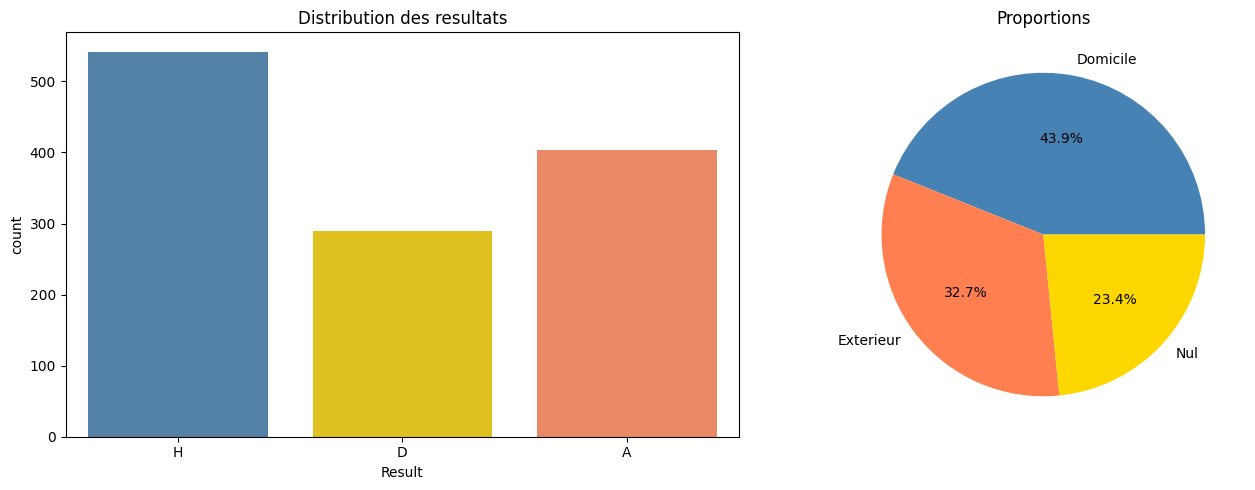

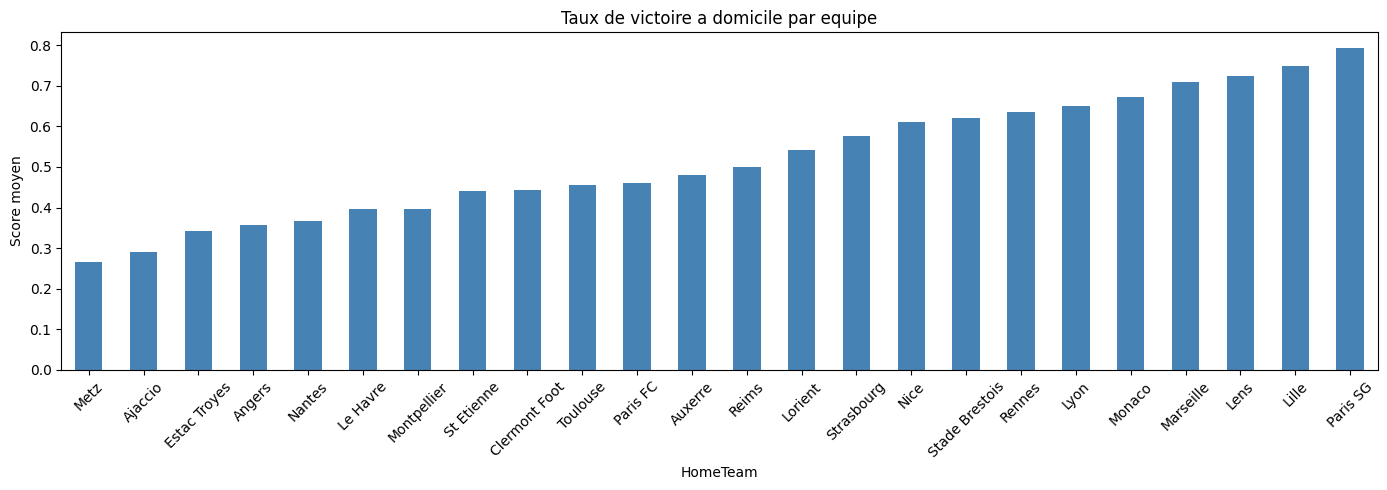

In [30]:
final_df['result_home'] = final_df['Result'].map({'H':1,'D':0.5,'A':0})
final_df['result_away'] = final_df['Result'].map({'H':0,'D':0.5,'A':1})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=final_df, x='Result', order=['H','D','A'], ax=axes[0],
              palette=['steelblue','gold','coral'])
axes[0].set_title('Distribution des resultats')
final_df['Result'].value_counts(normalize=True).reindex(['H','A','D']).plot(
    kind='pie', labels=['Domicile','Exterieur','Nul'],
    autopct='%1.1f%%', colors=['steelblue','coral','gold'], ax=axes[1])
axes[1].set_title('Proportions')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
final_df.groupby('HomeTeam')['result_home'].mean().sort_values().plot(
    kind='bar', color='steelblue', title='Taux de victoire a domicile par equipe')
plt.ylabel('Score moyen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# top10 = final_df['Referee'].value_counts().head(10).index
# plt.figure(figsize=(14, 5))
# sns.countplot(data=final_df[final_df['Referee'].isin(top10)],
#               x='Referee', hue='Result', hue_order=['H','D','A'])
# plt.title('Resultats par arbitre (Top 10)')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

## 7. Feature Engineering — Stats par lieu (saison entiere)

On calcule les statistiques separement selon que l'equipe joue a domicile ou a l'exterieur.
Cela capture l'effet du terrain — le PSG a domicile est different du PSG a l'exterieur.

In [31]:
def home_points(result): return 3 if result == 'H' else (1 if result == 'D' else 0)
def away_points(result): return 3 if result == 'A' else (1 if result == 'D' else 0)

# Stats quand l'equipe joue A DOMICILE
home_stats = final_df.groupby(['league.season','HomeTeam']).agg(
    gs_h=('HomeScore','sum'), gc_h=('AwayScore','sum'), gm_h=('HomeScore','count'),
    wins_h=('Result', lambda x: (x=='H').sum()),
).reset_index().rename(columns={'HomeTeam':'Team'})
home_stats['goals_scored_home']   = (home_stats['gs_h'] / home_stats['gm_h']).round(3)
home_stats['goals_conceded_home'] = (home_stats['gc_h'] / home_stats['gm_h']).round(3)
home_stats['win_rate_home']       = (home_stats['wins_h'] / home_stats['gm_h']).round(3)

# Stats quand l'equipe joue A L'EXTERIEUR
away_stats = final_df.groupby(['league.season','AwayTeam']).agg(
    gs_a=('AwayScore','sum'), gc_a=('HomeScore','sum'), gm_a=('AwayScore','count'),
    wins_a=('Result', lambda x: (x=='A').sum()),
).reset_index().rename(columns={'AwayTeam':'Team'})
away_stats['goals_scored_away']   = (away_stats['gs_a'] / away_stats['gm_a']).round(3)
away_stats['goals_conceded_away'] = (away_stats['gc_a'] / away_stats['gm_a']).round(3)
away_stats['win_rate_away']       = (away_stats['wins_a'] / away_stats['gm_a']).round(3)

# Classement final
hr = final_df.groupby(['league.season','HomeTeam']).apply(lambda g: pd.Series({
    'pts': g['Result'].apply(home_points).sum(),
    'gf': g['HomeScore'].sum(), 'ga': g['AwayScore'].sum()
})).reset_index().rename(columns={'HomeTeam':'Team'})
ar = final_df.groupby(['league.season','AwayTeam']).apply(lambda g: pd.Series({
    'pts': g['Result'].apply(away_points).sum(),
    'gf': g['AwayScore'].sum(), 'ga': g['HomeScore'].sum()
})).reset_index().rename(columns={'AwayTeam':'Team'})
st = pd.concat([hr,ar]).groupby(['league.season','Team']).sum().reset_index()
st['gd'] = st['gf']-st['ga']
st = st.sort_values(['league.season','pts','gd','gf'],ascending=[True,False,False,False])
st['season_rank'] = st.groupby('league.season').cumcount()+1
final_standings = st[['league.season','Team','season_rank']]

# Insertion via mapping
hs = home_stats.set_index(['league.season','Team'])
as_ = away_stats.set_index(['league.season','Team'])
rs = final_standings.set_index(['league.season','Team'])

for col, src, key in [
    ('home_goals_scored_home',   hs,  'goals_scored_home'),
    ('home_goals_conceded_home', hs,  'goals_conceded_home'),
    ('home_win_rate_home',       hs,  'win_rate_home'),
    ('away_goals_scored_away',   as_, 'goals_scored_away'),
    ('away_goals_conceded_away', as_, 'goals_conceded_away'),
    ('away_win_rate_away',       as_, 'win_rate_away'),
    ('home_season_rank',         rs,  'season_rank'),
    ('away_season_rank',         rs,  'season_rank'),
]:
    team = 'HomeTeam' if col.startswith('home') else 'AwayTeam'
    final_df[col] = final_df.set_index(['league.season', team]).index.map(src[key])

print('Stats par lieu inserees')

Stats par lieu inserees


## 8. Feature Engineering — Moyennes mobiles (Rolling Averages)

Les rolling averages capturent la **forme recente** de chaque equipe sur les 5 derniers matchs,
independamment de la saison.

**Principe anti-leakage :** le `.shift(1)` decale les valeurs d'un rang — ainsi le jogo courant
n'est jamais inclus dans sa propre moyenne. On n'utilise que ce qui s'est passe **avant** le match.

**Pourquoi c'est different des moyennes saison ?**
La moyenne saison dit : 'cette equipe est forte en general'.
Le rolling dit : 'cette equipe est en forme **maintenant**'.
Les deux sont complementaires.

In [36]:
def add_rolling_features(df, window=5):
    df = df.copy()

    # Empiler perspective domicile + exterieur pour chaque equipe
    home_df = df[['Date','HomeTeam','HomeScore','AwayScore']].rename(
        columns={'HomeTeam':'Team','HomeScore':'scored','AwayScore':'conceded'})
    away_df = df[['Date','AwayTeam','AwayScore','HomeScore']].rename(
        columns={'AwayTeam':'Team','AwayScore':'scored','HomeScore':'conceded'})
    all_matches = pd.concat([home_df, away_df]).sort_values('Date').reset_index(drop=True)

    # Rolling avec shift(1) — le jeu courant n'est pas inclus
    all_matches['roll_scored']   = all_matches.groupby('Team')['scored'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    all_matches['roll_conceded'] = all_matches.groupby('Team')['conceded'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())

    # Taux de victoire sur les derniers matchs
    home_wins = df[['Date','HomeTeam','Result']].rename(columns={'HomeTeam':'Team'})
    home_wins['won'] = (home_wins['Result']=='H').astype(int)
    away_wins = df[['Date','AwayTeam','Result']].rename(columns={'AwayTeam':'Team'})
    away_wins['won'] = (away_wins['Result']=='A').astype(int)
    all_wins = pd.concat([home_wins[['Date','Team','won']],
                          away_wins[['Date','Team','won']]]).sort_values('Date')
    all_wins['roll_win_rate'] = all_wins.groupby('Team')['won'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())

    # Lookup tables
    stats_lookup = all_matches.groupby(['Date','Team'])[['roll_scored','roll_conceded']].first()
    win_lookup   = all_wins.groupby(['Date','Team'])['roll_win_rate'].first()

    # Insertion dans le dataframe principal
    df['home_rolling_scored']   = df.set_index(['Date','HomeTeam']).index.map(stats_lookup['roll_scored']).fillna(0).round(3).values
    df['home_rolling_conceded'] = df.set_index(['Date','HomeTeam']).index.map(stats_lookup['roll_conceded']).fillna(0).round(3).values
    df['home_rolling_win_rate'] = df.set_index(['Date','HomeTeam']).index.map(win_lookup).fillna(0).round(3).values
    df['away_rolling_scored']   = df.set_index(['Date','AwayTeam']).index.map(stats_lookup['roll_scored']).fillna(0).round(3).values
    df['away_rolling_conceded'] = df.set_index(['Date','AwayTeam']).index.map(stats_lookup['roll_conceded']).fillna(0).round(3).values
    df['away_rolling_win_rate'] = df.set_index(['Date','AwayTeam']).index.map(win_lookup).fillna(0).round(3).values

    return df

print('Calcul des rolling averages (5 derniers matchs)...')
final_df = add_rolling_features(final_df, window=5)

# Verification — exemple PSG vs Marseille
ex = final_df[final_df['HomeTeam']=='Lyon'][[
    'Date','HomeTeam','AwayTeam',
    'home_rolling_scored','home_rolling_conceded','home_rolling_win_rate'
]].tail(8)
print('\nExemple rolling PSG (domicile) :')
print(ex.to_string(index=False))

Calcul des rolling averages (5 derniers matchs)...

Exemple rolling PSG (domicile) :
      Date HomeTeam       AwayTeam  home_rolling_scored  home_rolling_conceded  home_rolling_win_rate
2025-11-09     Lyon       Paris SG                  1.6                    1.8                    0.2
2025-11-30     Lyon         Nantes                  1.4                    1.4                    0.2
2025-12-14     Lyon       Le Havre                  1.0                    0.8                    0.2
2026-01-18     Lyon Stade Brestois                  1.4                    0.4                    0.6
2026-02-01     Lyon          Lille                  2.2                    1.0                    0.8
2026-02-15     Lyon           Nice                  2.4                    0.8                    1.0
2026-03-08     Lyon       Paris FC                  1.4                    1.2                    0.6
2026-03-22     Lyon         Monaco                  1.2                    1.4                    0

## 9. Matrice de correlation

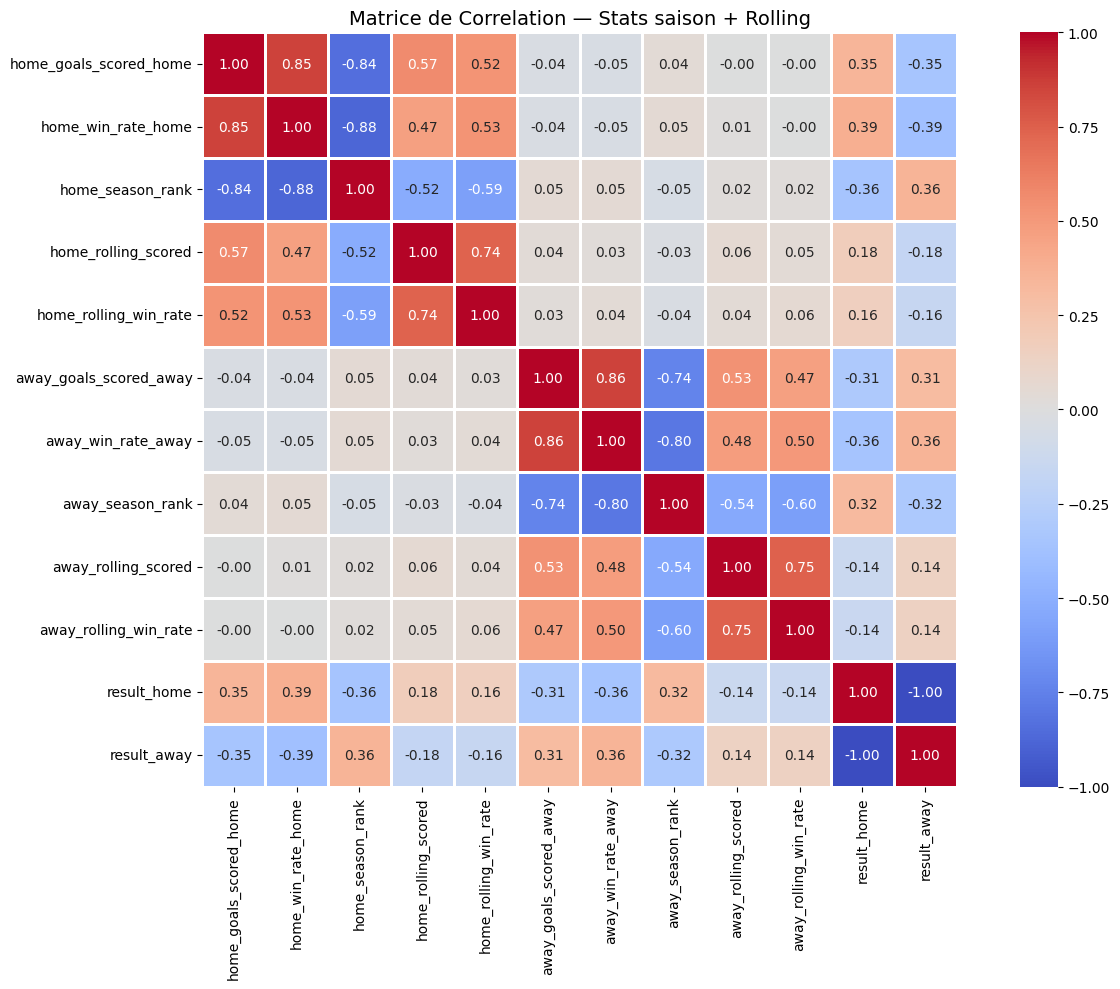

In [33]:
cols_corr = [
    'home_goals_scored_home','home_win_rate_home','home_season_rank',
    'home_rolling_scored','home_rolling_win_rate',
    'away_goals_scored_away','away_win_rate_away','away_season_rank',
    'away_rolling_scored','away_rolling_win_rate',
    'result_home','result_away'
]
corr = final_df[cols_corr].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Matrice de Correlation — Stats saison + Rolling', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Export

In [34]:
final_df.to_csv('../Data/dataset/completed_match_dataset_final.csv', index=False)
print(f'Dataset exporte : {final_df.shape[0]} lignes, {final_df.shape[1]} colonnes')
final_df.tail()

Dataset exporte : 1234 lignes, 39 colonnes


,league.season,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,result_home,result_away,home_goals_scored_home,home_goals_conceded_home,home_win_rate_home,away_goals_scored_away,away_goals_conceded_away,away_win_rate_away,home_season_rank,away_season_rank,home_rolling_scored,home_rolling_conceded,home_rolling_win_rate,away_rolling_scored,away_rolling_conceded,away_rolling_win_rate
1229,2025,Nantes,Strasbourg,2,3,2026-03-22,19:45,A,1,1,D,14,13,9,9,15,17,3,6,3,3,0,0,0.0,1.0,1.000,1.857,0.143,1.571,1.714,0.286,17,8,0.6,1.2,0.2,1.2,0.8,0.2
1230,2025,Paris FC,Le Havre,3,2,2026-03-22,16:15,H,2,0,H,15,20,4,6,9,13,9,5,0,1,1,0,1.0,0.0,1.385,1.846,0.308,0.538,1.769,0.077,13,14,0.6,1.4,0.2,0.4,1.2,0.2
1231,2025,Lyon,Monaco,1,2,2026-03-22,14:00,A,1,0,H,15,21,4,7,11,19,2,6,1,3,1,0,0.0,1.0,1.615,0.769,0.692,1.385,1.462,0.385,4,6,1.2,1.4,0.2,2.6,0.8,1.0
1232,2025,Marseille,Lille,1,2,2026-03-22,16:15,A,1,0,H,14,11,3,4,8,6,6,4,1,3,0,0,0.0,1.0,2.429,1.214,0.643,1.571,1.429,0.500,3,5,1.4,1.2,0.6,1.2,0.6,0.6
1233,2025,Rennes,Metz,0,0,2026-03-22,16:15,D,0,0,D,25,7,8,2,13,13,8,2,1,3,0,0,0.5,0.5,1.714,1.000,0.500,0.857,2.643,0.071,7,18,2.4,0.6,0.8,0.8,2.8,0.0
